In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df1 = pd.read_csv('spam.csv', encoding='latin-1')
df1.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
# Step 1: Keep only required columns
df1 = df1[['v1', 'v2']]

# Step 2: Rename columns
df1.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)

# Step 3: Convert labels (ham → 0, spam → 1)
df1['target'] = df1['target'].map({'ham': 0, 'spam': 1})

# Step 4: Remove any missing values (optional but recommended)
df1.dropna(inplace=True)

# Step 5: Remove duplicate messages (optional but useful)
df1.drop_duplicates(inplace=True)

# Step 6: Reset index
df1.reset_index(drop=True, inplace=True)

# Step 7: Save cleaned dataset
#df1.to_csv("cleaned_spam.csv", index=False)

# Preview
df1.head()


,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df1.shape

(5169, 2)

In [ ]:
df1.isnull().sum()

,0
target,0
text,0


In [ ]:
df1.duplicated().sum()

np.int64(0)

In [ ]:
'''# Lowercase text
df['text'] = df['text'].str.lower()

# Remove extra spaces
df['text'] = df['text'].str.strip()'''

"# Lowercase text\ndf['text'] = df['text'].str.lower()\n\n# Remove extra spaces\ndf['text'] = df['text'].str.strip()"

In [ ]:
df1.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df1['target'].value_counts()

,count
target,
0,4516
1,653


second dataset

In [ ]:
df4 = pd.read_csv('spam_ham_india4.csv', encoding='latin-1')
df4.head()

,Label,Msg
0,spam,CONGRATULATIONS! FREE 2GB data is yours! Claim...
1,spam,Hi! Thank you for being with Vi-India's FASTES...
2,spam,"As part of Cyber Swachhta Pakhwada, CERT-In Go..."
3,ham,I will try to manage took tablets
4,spam,Study from Home with Vi!! Watch Kite Victers C...


In [ ]:
# Step 1: Keep only required columns
#df4 = df4[['Label', 'Msg']]

# Step 2: Rename columns
df4.rename(columns={
    'Label': 'target',
    'Msg': 'text'
}, inplace=True)
df4['target'] = df4['target'].str.lower().str.strip()
df4['target'] = df4['target'].map({
    'ham': 0,
    'spam': 1
})

# Step 4: Remove missing values
df4.dropna(inplace=True)

# Step 5: Remove duplicates
df4.drop_duplicates(inplace=True)

# Step 7: Reset index
df4.reset_index(drop=True, inplace=True)

# Step 8: Save cleaned dataset
#df4.to_csv("cleaned_spam_ham_india4.csv", index=False)

# Preview
df4.head()

,target,text
0,1,CONGRATULATIONS! FREE 2GB data is yours! Claim...
1,1,Hi! Thank you for being with Vi-India's FASTES...
2,1,"As part of Cyber Swachhta Pakhwada, CERT-In Go..."
3,0,I will try to manage took tablets
4,1,Study from Home with Vi!! Watch Kite Victers C...


In [ ]:
df4.shape

(2061, 2)

In [ ]:
df4['target'].value_counts()

,count
target,
0,1325
1,736


In [ ]:
#df5['target'].value_counts()

merge all the dataset


In [ ]:
# Step 1: Combine all datasets
df= pd.concat([df1, df4], ignore_index=True)

# Step 2: Remove duplicates (very important after merging)
df.drop_duplicates(inplace=True)

# Step 3: Remove missing values (safety step)
df.dropna(inplace=True)

# Step 4: Ensure correct data types
df['target'] = df['target'].astype(int)
df['text'] = df['text'].astype(str)

# Step 5: Reset index
df.reset_index(drop=True, inplace=True)

# Step 6: Shuffle dataset (important for ML)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Step 7: Save final dataset
#df.to_csv("final_spam_dataset.csv", index=False)

# Preview
df.head()


,target,text
0,0,Are you the cutest girl in the world or what
1,0,""" Let's first focus on the international marke..."
2,0,"Babe, have you got enough money to pick up bre..."
3,0,""" Due to escalating geopolitical tensions, par..."
4,0,THING R GOOD THANX GOT EXAMS IN MARCH IVE DONE...


In [ ]:
print("\nFinal Dataset Shape:", df.shape)


Final Dataset Shape: (7229, 2)


In [ ]:
# Check class distribution
print("\nClass Distribution:")
df['target'].value_counts()


Class Distribution:


,count
target,
0,5840
1,1389


EDA

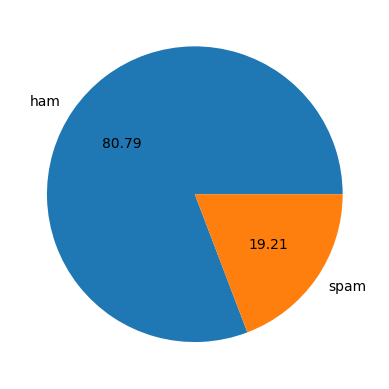

In [ ]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

# Feature Engineering


In [ ]:
!pip install nltk

In [ ]:
import nltk

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
df['num_characters']=df['text'].apply(len)

In [ ]:
df.head()

,target,text,num_characters
0,0,Are you the cutest girl in the world or what,44
1,0,""" Let's first focus on the international marke...",534
2,0,"Babe, have you got enough money to pick up bre...",105
3,0,""" Due to escalating geopolitical tensions, par...",517
4,0,THING R GOOD THANX GOT EXAMS IN MARCH IVE DONE...,126


In [ ]:
# Counting Number of Words
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [ ]:
df.head()

,target,text,num_characters,num_words
0,0,Are you the cutest girl in the world or what,44,10
1,0,""" Let's first focus on the international marke...",534,99
2,0,"Babe, have you got enough money to pick up bre...",105,26
3,0,""" Due to escalating geopolitical tensions, par...",517,86
4,0,THING R GOOD THANX GOT EXAMS IN MARCH IVE DONE...,126,29


In [ ]:
# Counting Number of Sentences
df['num_sentences']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [ ]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,Are you the cutest girl in the world or what,44,10,1
1,0,""" Let's first focus on the international marke...",534,99,4
2,0,"Babe, have you got enough money to pick up bre...",105,26,2
3,0,""" Due to escalating geopolitical tensions, par...",517,86,4
4,0,THING R GOOD THANX GOT EXAMS IN MARCH IVE DONE...,126,29,3


In [ ]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,7229.000000,7229.000000,7229.000000
mean,86.537419,19.153548,1.957255
std,72.280088,15.280171,1.683845
min,1.000000,1.000000,1.000000
25%,35.000000,8.000000,1.000000
50%,64.000000,15.000000,1.000000
75%,133.000000,27.000000,3.000000
max,910.000000,220.000000,52.000000


In [ ]:
#ham
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5840.000000,5840.000000,5840.000000
mean,70.804110,16.572945,1.708048
std,67.774259,14.865008,1.295468
min,1.000000,1.000000,1.000000
25%,31.000000,8.000000,1.000000
50%,50.000000,12.000000,1.000000
75%,87.000000,21.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
#spam
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,1389.000000,1389.000000,1389.000000
mean,152.687545,30.003600,3.005040
std,49.622599,11.852084,2.518943
min,13.000000,2.000000,1.000000
25%,135.000000,25.000000,2.000000
50%,151.000000,29.000000,3.000000
75%,159.000000,33.000000,4.000000
max,635.000000,193.000000,52.000000


In [ ]:
import seaborn as sns

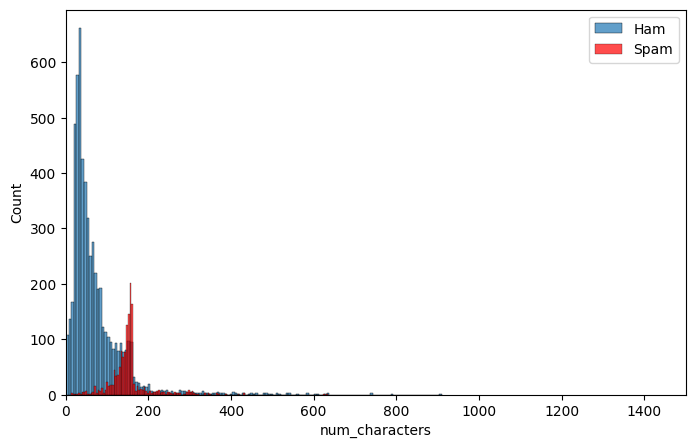

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df[df['target']==0]['num_characters'], label='Ham', alpha=0.7)
sns.histplot(df[df['target']==1]['num_characters'], color='red', label='Spam', alpha=0.7)

plt.xlim(0, 1500)
plt.legend()
plt.show()

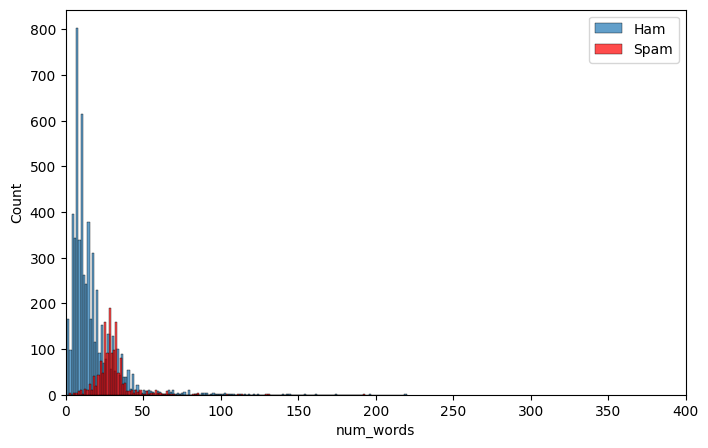

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df[df['target']==0]['num_words'],label='Ham', alpha=0.7)
sns.histplot(df[df['target']==1]['num_words'],color='red', label='Spam', alpha=0.7)
plt.xlim(0, 400)
plt.legend()
plt.show()

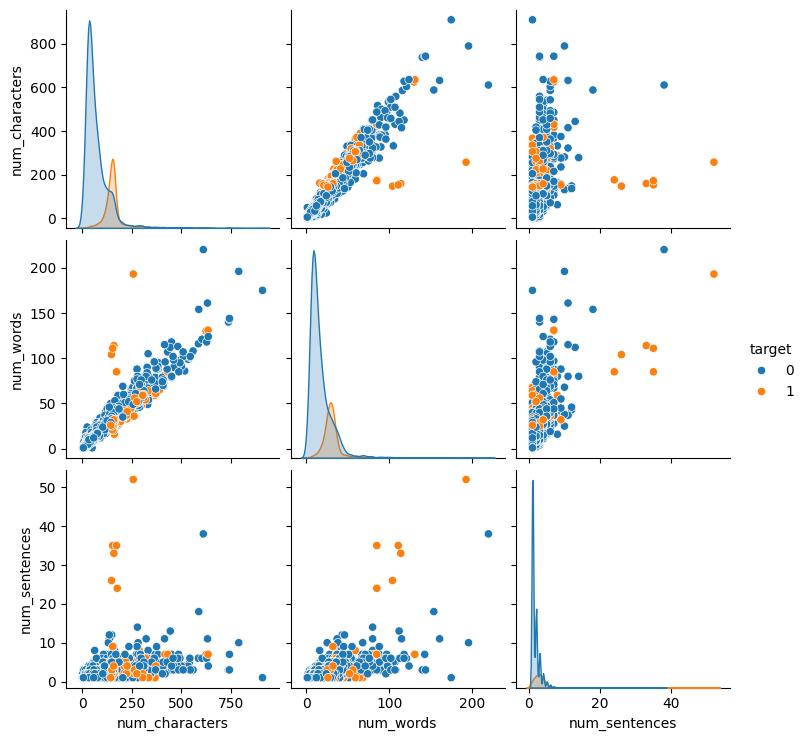

In [ ]:
sns.pairplot(df,hue='target')

In [ ]:
df[['target', 'num_characters', 'num_words', 'num_sentences']].corr()

,target,num_characters,num_words,num_sentences
target,1.000000,0.446362,0.346321,0.303490
num_characters,0.446362,1.000000,0.955103,0.507132
num_words,0.346321,0.955103,1.000000,0.638086
num_sentences,0.303490,0.507132,0.638086,1.000000


<Axes: >

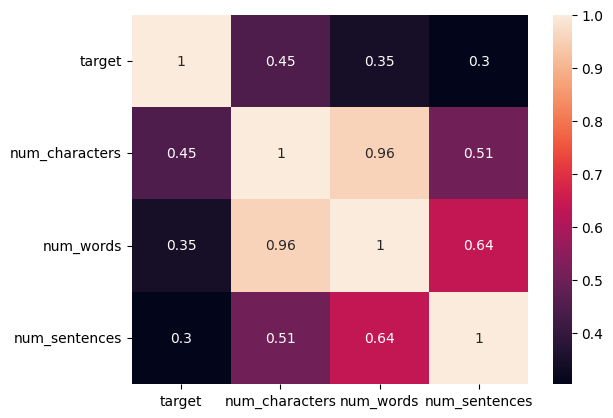

In [ ]:
sns.heatmap(df[['target', 'num_characters', 'num_words', 'num_sentences']].corr(),annot=True)

In [ ]:
df['has_number'] = df['text'].apply(lambda x: 1 if any(char.isdigit() for char in x) else 0)

In [ ]:
df.head(20)

,target,text,num_characters,num_words,num_sentences,has_number
0,0,Are you the cutest girl in the world or what,44,10,1,0
1,0,""" Let's first focus on the international marke...",534,99,4,1
2,0,"Babe, have you got enough money to pick up bre...",105,26,2,0
3,0,""" Due to escalating geopolitical tensions, par...",517,86,4,0
4,0,THING R GOOD THANX GOT EXAMS IN MARCH IVE DONE...,126,29,3,1
5,0,Yup ok...,9,3,1,0
6,1,Do not click on unknown links offering cashbac...,120,23,2,0
7,0,Members who buy must register the purchase det...,101,20,2,0
8,1,Free video camera phones with Half Price line ...,146,26,2,1
9,0,great princess! I love giving and receiving or...,148,37,5,0


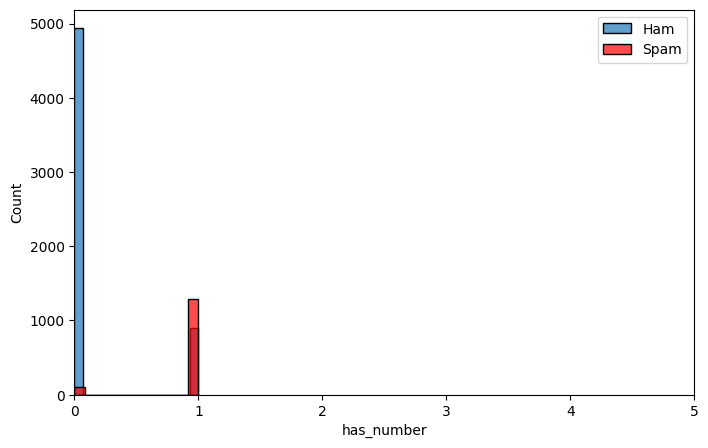

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df[df['target']==0]['has_number'],label='Ham', alpha=0.7)
sns.histplot(df[df['target']==1]['has_number'],color='red', label='Spam', alpha=0.7)
plt.xlim(0, 5)
plt.legend()
plt.show()

Lowercase
↓

Remove URLs / emails / numbers
↓

Remove special characters
↓

Tokenization
↓

Remove stopwords
↓

Lemmatization
↓

Feature Engineering (num_words, etc.)
↓

TF-IDF (with n-grams)
↓

SMOTE
↓

Model Training

## **Data Preprocessing**
>* lower case

>* Tokenization

>* Removing special characters

>* Removing stop words and punctuation

>* stemming

In [ ]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords.words('english')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
import re
def transform_text(text):

    # 1. Lowercase
    text = text.lower()
    # Add this inside transform_text
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # 2. Remove URLs & emails
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)

    # 3. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 4. Handle repeated characters (e.g., freeeee → freee)
    text = re.sub(r'(.)\1+', r'\1\1', text)

    # 5. Tokenization
    words = nltk.word_tokenize(text)

    # 6. Remove stopwords + non-alphabetic
    #words=[]
    words = [word for word in words if word.isalpha() and word not in stop_words and len(word)>1]
    '''for i in text:
      if i.isalpha() and i not in stop_words:
          words.append(i)'''

    # 7. Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [ ]:
# Making new transformed text column
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
df['transform_text']=df['text'].apply(transform_text)

In [ ]:
df.head()

,target,text,num_characters,num_words,num_sentences,has_number,transform_text
0,0,Are you the cutest girl in the world or what,44,10,1,0,cutest girl world
1,0,""" Let's first focus on the international marke...",534,99,4,1,let first focus international market due conti...
2,0,"Babe, have you got enough money to pick up bre...",105,26,2,0,babe got enough money pick bread milk give bac...
3,0,""" Due to escalating geopolitical tensions, par...",517,86,4,0,due escalating geopolitical tension particular...
4,0,THING R GOOD THANX GOT EXAMS IN MARCH IVE DONE...,126,29,3,1,thing good thanx got exam march ive done revis...


In [ ]:
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

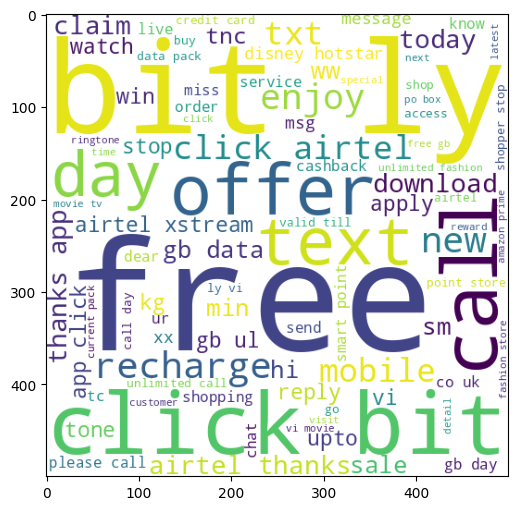

In [ ]:
spam_wc=wc.generate(df[df['target']==1]['transform_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

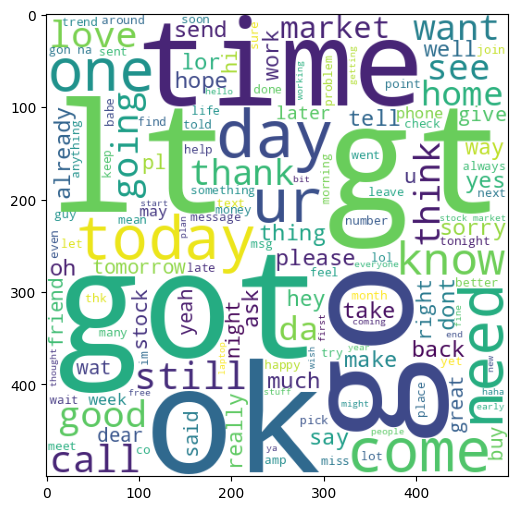

In [ ]:
ham_wc=wc.generate(df[df['target']==0]['transform_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [ ]:
# Counting the number of words which is used most
spam_corpus=[]
for msg in df[df['target']==1]['transform_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)
len(spam_corpus)

24008

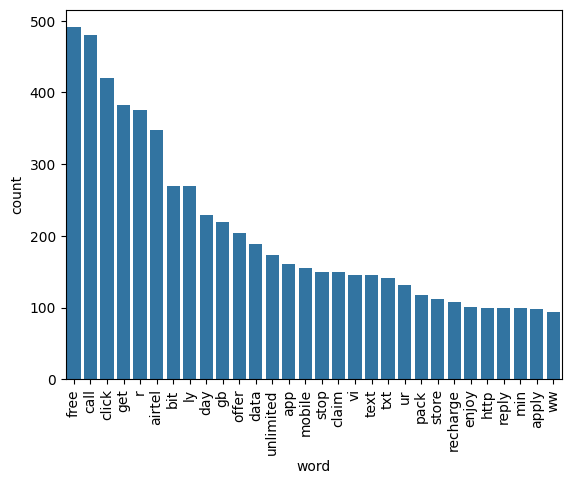

In [ ]:
from collections import Counter
temp_df = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])

sns.barplot(x='word', y='count', data=temp_df)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
ham_corpus=[]
for msg in df[df['target']==0]['transform_text'].tolist():
  for word in msg.split():
    ham_corpus.append(word)
len(ham_corpus)

42920

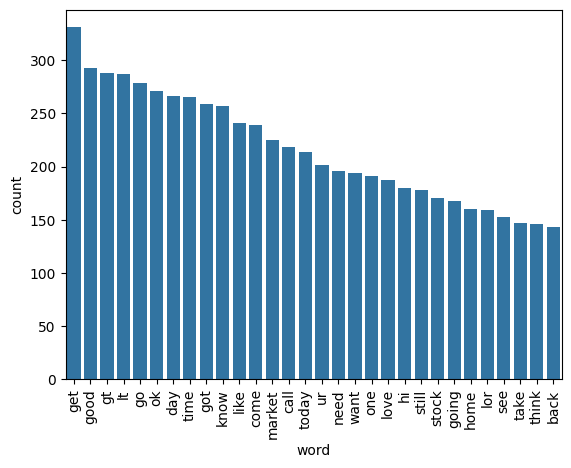

In [ ]:
temp_df = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])

sns.barplot(x='word', y='count', data=temp_df)
plt.xticks(rotation='vertical')
plt.show()

## **4. Texting Model Building**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Reset index (VERY IMPORTANT)
df = df.reset_index(drop=True)

# Split everything together
X_train_text, X_test_text, y_train, y_test, train_idx, test_idx = train_test_split(
    df['transform_text'],
    df['target'],
    df.index,   # 👈 track indices
    test_size=0.2,
    random_state=42,
    stratify=df['target']
)

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=7000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train = tfidf.fit_transform(X_train_text).toarray()
X_test = tfidf.transform(X_test_text).toarray()

# Add extra features correctly
X_train_extra = df.loc[train_idx, ['num_characters','num_words','num_sentences']].values
X_test_extra = df.loc[test_idx, ['num_characters','num_words','num_sentences']].values

# Combine
X_train = np.hstack((X_train, X_train_extra))
X_test = np.hstack((X_test, X_test_extra))

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

## **5.Model Building**

In [ ]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier


In [ ]:
mnb = MultinomialNB()
Lg = LogisticRegression(max_iter=1000,class_weight='balanced')
SVM = SVC(kernel='linear', class_weight='balanced')
# RF = RandomForestClassifier()
# gnb = GaussianNB()
# bnb = BernoulliNB()
# dt = DecisionTreeClassifier()
# knn = KNeighborsClassifier()
# ada = AdaBoostClassifier()
# gb = GradientBoostingClassifier()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import time
from sklearn.metrics import roc_auc_score

results = []

# Define the models dictionary
models = {
    'MultinomialNB': mnb,
    # 'GaussianNB' : gnb,
    # 'BernoulliNB' : bnb,
    'LogisticRegression': Lg,
    'SVM': SVM,
    # 'RandomForestClassifier': RF,
    # 'Decision Tree': dt,
    # 'KNN': knn,
    # 'AdaBoost': ada,
    # 'Gradient Boosting': gb

}

for name, model in models.items():
    start_train = time.time()
    model.fit(X_train_resampled , y_train_resampled)
    end_train = time.time()

    start_pred = time.time()
    y_pred = model.predict(X_test)
    end_pred = time.time()

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    support = len(y_test)
    train_time = end_train - start_train
    pred_time = end_pred - start_pred

    results.append([name,
    round(accuracy * 100, 2),
    round(precision * 100, 2),
    round(recall * 100, 2),
    round(roc_auc * 100, 2),
    round(f1 * 100, 2),
    support,
    round(train_time, 3),
    round(pred_time, 3)
    ])
    #results.append([name, accuracy, precision, recall,roc_auc, f1, support ,train_time,
        #pred_time])'''

In [ ]:
results_df = pd.DataFrame(results, columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "ROC AUC",
    "F1-score",
    "Support",
    "Training Time",
    "Prediction Time"
])

results_df

,Model,Accuracy,Precision,Recall,ROC AUC,F1-score,Support,Training Time,Prediction Time
0,MultinomialNB,94.95,81.35,95.68,95.23,87.93,1446,0.397,0.041
1,LogisticRegression,97.44,93.19,93.53,95.95,93.36,1446,33.126,0.054
2,SVM,98.34,96.01,95.32,97.19,95.67,1446,668.381,11.611


In [ ]:
# Combined score
results_df['Score'] = (0.2 * results_df['Accuracy']) + (0.4 * results_df['Precision'])+(0.4 * results_df['Recall'])

# Sort
results_df = results_df.sort_values(by='Score', ascending=False)

print("\n🔷 Model Comparison:\n")
print(results_df)

# Best model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print("\n🏆 Best Model:", best_model_name)



🔷 Model Comparison:

                Model  Accuracy  Precision  Recall  ROC AUC  F1-score  \
2                 SVM     98.34      96.01   95.32    97.19     95.67   
1  LogisticRegression     97.44      93.19   93.53    95.95     93.36   
0       MultinomialNB     94.95      81.35   95.68    95.23     87.93   

   Support  Training Time  Prediction Time   Score  
2     1446        668.381           11.611  96.200  
1     1446         33.126            0.054  94.176  
0     1446          0.397            0.041  89.802  

🏆 Best Model: SVM


In [ ]:
# from joblib import dump
# dump(tfidf, "vectorizer.joblib")
# dump(best_model, "model.joblib")

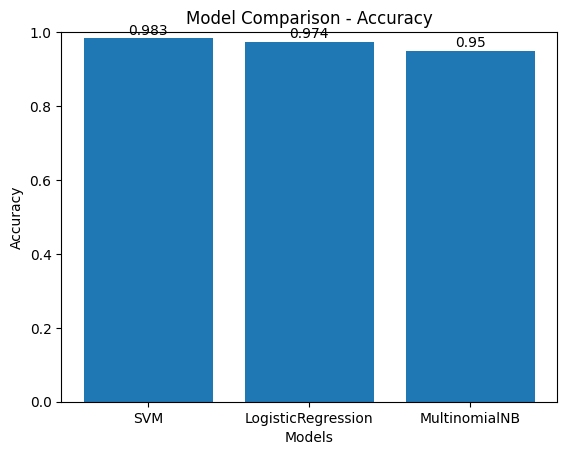

In [ ]:
# Accuracy Graph
plt.figure()
plt.bar(results_df['Model'], results_df['Accuracy'] / 100)
plt.title("Model Comparison - Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(results_df['Accuracy'] / 100):
    plt.text(i, v + 0.01, str(round(v, 3)), ha='center')
plt.show()

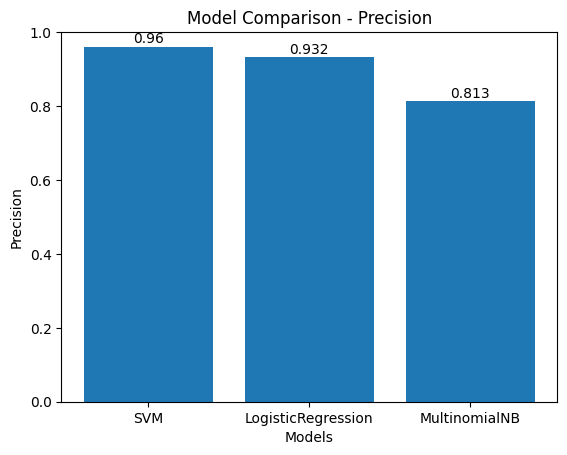

In [ ]:
# Precision Graph
plt.figure()
plt.bar(results_df['Model'], results_df['Precision'] / 100)
plt.title("Model Comparison - Precision")
plt.xlabel("Models")
plt.ylabel("Precision")
plt.ylim(0, 1)
for i, v in enumerate(results_df['Precision'] / 100):
    plt.text(i, v + 0.01, str(round(v, 3)), ha='center')
plt.show()

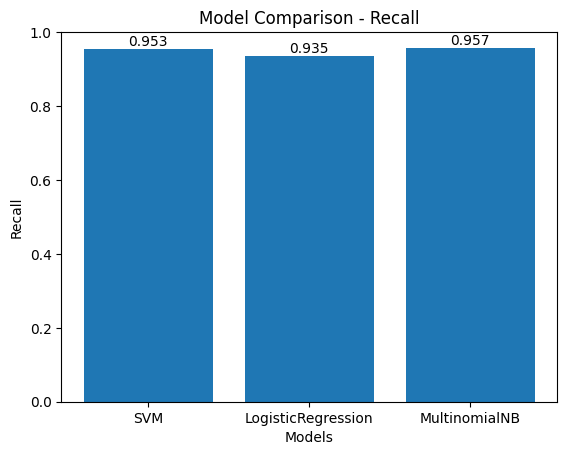

In [ ]:
# Recall Graph
plt.figure()
plt.bar(results_df['Model'], results_df['Recall'] / 100)
plt.title("Model Comparison - Recall")
plt.xlabel("Models")
plt.ylabel("Recall")
plt.ylim(0, 1)
for i, v in enumerate(results_df['Recall'] / 100):
    plt.text(i, v + 0.01, str(round(v, 3)), ha='center')
plt.show()

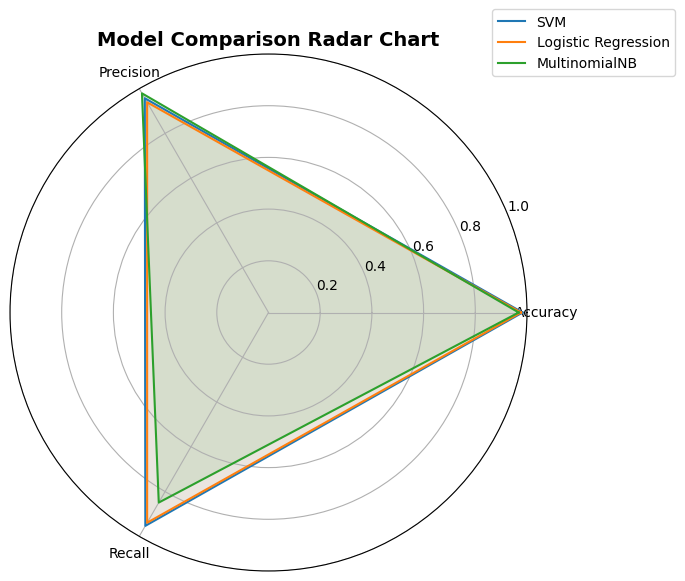

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Models
models = ['SVM', 'Logistic Regression', 'MultinomialNB']

# Replace with your actual values
accuracy = [0.983, 0.977, 0.968]
precision = [0.957, 0.939, 0.979]
recall = [0.953, 0.939, 0.849]

# Combine metrics for each model
data = [
    [accuracy[0], precision[0], recall[0]],  # SVM
    [accuracy[1], precision[1], recall[1]],  # LR
    [accuracy[2], precision[2], recall[2]]   # NB
]

labels = ['Accuracy', 'Precision', 'Recall']
num_vars = len(labels)

# Angles for radar chart
angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the loop

plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

# Plot each model
for i, model_data in enumerate(data):
    values = model_data + model_data[:1]  # close shape
    ax.plot(angles, values, label=models[i])
    ax.fill(angles, values, alpha=0.1)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)

plt.title("Model Comparison Radar Chart", fontsize=14, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()